# Training Analysis: Q-Learning vs Q-Learning Crisp vs Q-Learning Fuzzy

Comparative analysis of Q-Table size, cumulative reward, and per-step reward between Q-Learning, Q-Learning Crisp, and Q-Learning Fuzzy models.

In [17]:
import glob
import os

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

DATA_DIR = 'data/training/60-episodes'

# Model definitions: display name -> file glob, plot color, marker
MODEL_SPECS = {
    'Q-Learning':       {'pattern': 'train_qlearning_*.csv',      'color': '#2196F3', 'marker': 'o'},
    'Q-Learning Crisp': {'pattern': 'train_qlearningcrisp_*.csv', 'color': '#4CAF50', 'marker': '^'},
    'Q-Learning Fuzzy': {'pattern': 'train_qlearningfuzzy_*.csv', 'color': '#FF5722', 'marker': 's'},
}


def load_one(pattern):
    matches = glob.glob(os.path.join(DATA_DIR, pattern))
    if not matches:
        raise FileNotFoundError(f'No file matching {pattern} in {DATA_DIR}')
    return pd.read_csv(sorted(matches)[0])


# Load data for each model
dfs = {name: load_one(spec['pattern']) for name, spec in MODEL_SPECS.items()}
COLORS = {name: spec['color'] for name, spec in MODEL_SPECS.items()}
MARKERS = {name: spec['marker'] for name, spec in MODEL_SPECS.items()}

# Common episodes across all models (used for fair comparison)
episode_sets = [set(df['episode'].unique()) for df in dfs.values()]
common_episodes = sorted(set.intersection(*episode_sets))
dfs_cmp = {name: df[df['episode'].isin(common_episodes)].copy() for name, df in dfs.items()}

for name, df in dfs.items():
    print(f'{name:<18}: {len(df)} steps, {df["episode"].nunique()} episodes')
print(f'Common episodes   : {len(common_episodes)} (used for comparison)')
print(f'Columns: {list(next(iter(dfs.values())).columns)}')

Q-Learning        : 1800 steps, 60 episodes
Q-Learning Crisp  : 1800 steps, 60 episodes
Q-Learning Fuzzy  : 1800 steps, 60 episodes
Common episodes   : 60 (used for comparison)
Columns: ['timestamp', 'episode', 'step', 'action', 'reward', 'cumulative_reward', 'episode_reward', 'epsilon', 'q_table_size', 'active_states', 'iteration', 'replica_state', 'cpu_usage', 'memory_usage', 'response_time', 'response_time_percentage', 'r_rt', 'r_cost']


## 1. Q-Table Size Growth

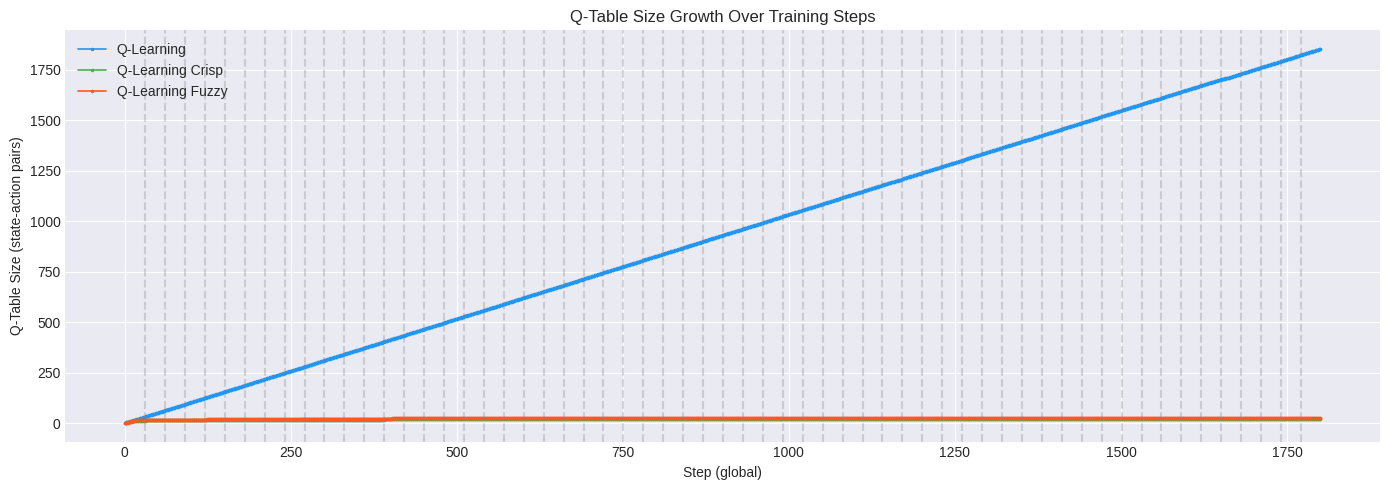


Final Q-Table sizes:
  Q-Learning        : 1853
  Q-Learning Crisp  : 22
  Q-Learning Fuzzy  : 24
  Q-Learning is 84.2x larger than Q-Learning Crisp
  Q-Learning Fuzzy is 1.1x larger than Q-Learning Crisp


In [18]:
# --- Q-Table size over all steps ---
fig, ax = plt.subplots(figsize=(14, 5))

ref_df = next(iter(dfs.values()))
for name, df in dfs.items():
    steps = range(1, len(df) + 1)
    ax.plot(steps, df['q_table_size'], marker='.', markersize=3, linewidth=1.2,
            label=name, color=COLORS[name])

ax.set_xlabel('Step (global)')
ax.set_ylabel('Q-Table Size (state-action pairs)')
ax.set_title('Q-Table Size Growth Over Training Steps')
ax.legend()

# Add episode boundaries (based on first model)
for ep in ref_df['episode'].unique()[1:]:
    idx = ref_df[ref_df['episode'] == ep].index[0]
    ax.axvline(x=idx + 1, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nFinal Q-Table sizes:')
finals = {name: df['q_table_size'].iloc[-1] for name, df in dfs.items()}
for name, val in finals.items():
    print(f'  {name:<18}: {val}')
smallest = min(finals, key=finals.get)
for name, val in finals.items():
    if name != smallest and finals[smallest] > 0:
        print(f'  {name} is {val / finals[smallest]:.1f}x larger than {smallest}')

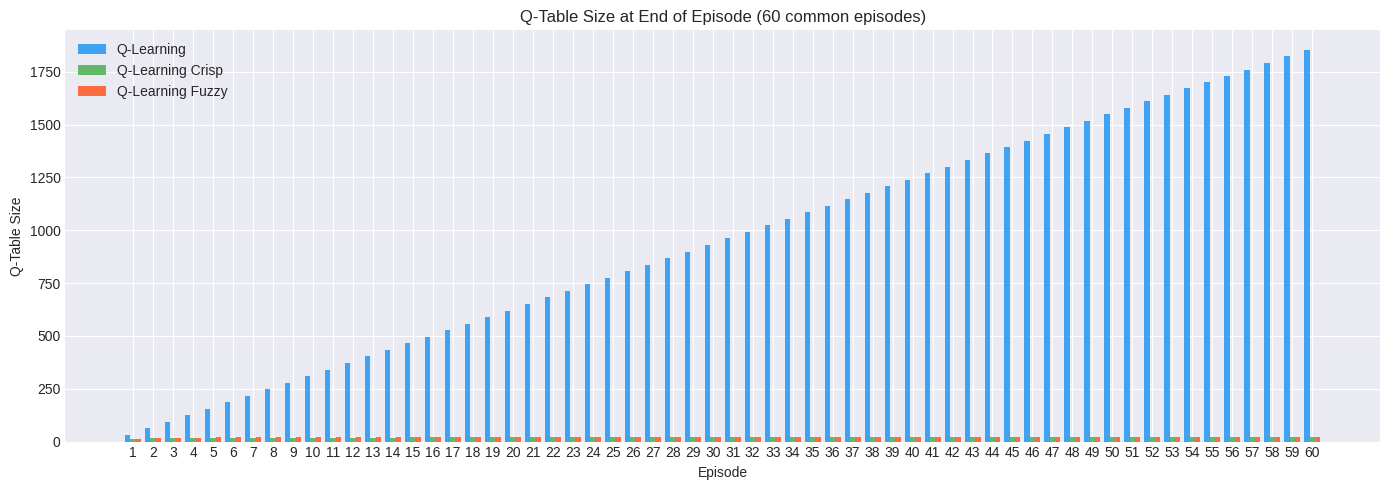

In [19]:
# --- Q-Table size at end of each episode (common episodes only) ---
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(common_episodes))
n = len(dfs_cmp)
width = 0.8 / n

for i, (name, df_cmp) in enumerate(dfs_cmp.items()):
    ep_end = df_cmp.groupby('episode')['q_table_size'].last()
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, ep_end.values, width, label=name, color=COLORS[name], alpha=0.85)

ax.set_xlabel('Episode')
ax.set_ylabel('Q-Table Size')
ax.set_title(f'Q-Table Size at End of Episode ({len(common_episodes)} common episodes)')
ax.set_xticks(x)
ax.set_xticklabels(common_episodes)
ax.legend()

plt.tight_layout()
plt.show()

## 2. Cumulative Reward per Episode

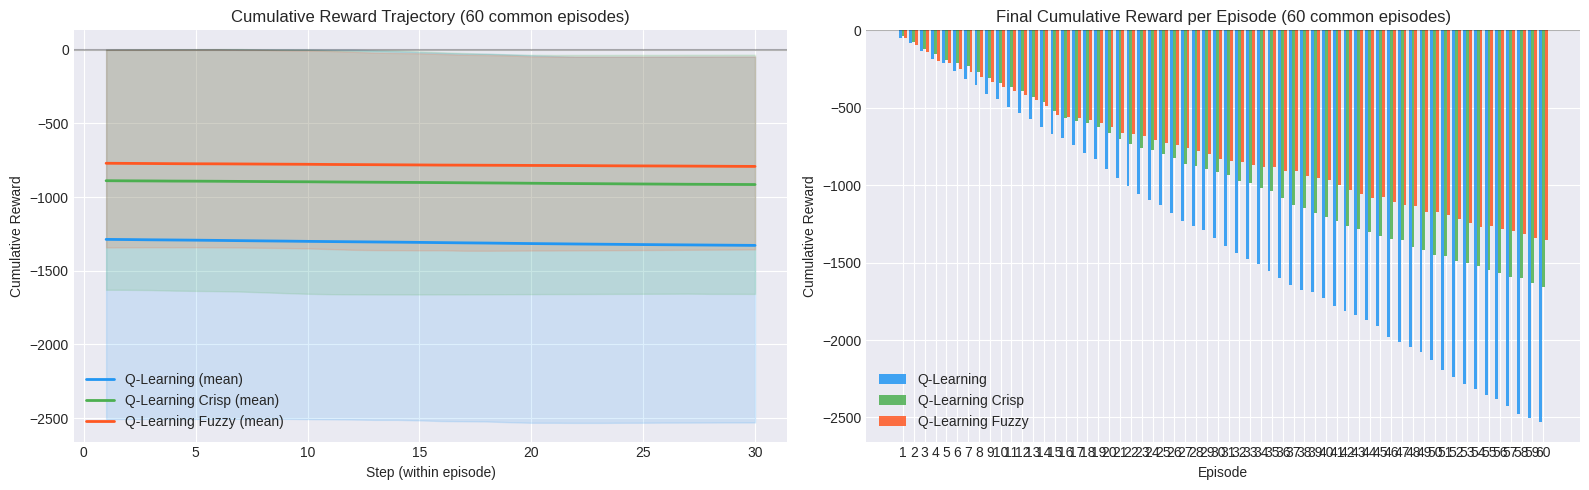

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Mean cumulative reward trajectory with min/max bands ---
ax = axes[0]
for name, df_cmp in dfs_cmp.items():
    stats = df_cmp.groupby('step')['cumulative_reward'].agg(['mean', 'min', 'max'])
    ax.plot(stats.index, stats['mean'], linewidth=2, label=f'{name} (mean)', color=COLORS[name])
    ax.fill_between(stats.index, stats['min'], stats['max'], alpha=0.15, color=COLORS[name])

ax.set_xlabel('Step (within episode)')
ax.set_ylabel('Cumulative Reward')
ax.set_title(f'Cumulative Reward Trajectory ({len(common_episodes)} common episodes)')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# --- Right: Final cumulative reward per episode (bar chart, common episodes) ---
ax = axes[1]
x = np.arange(len(common_episodes))
n = len(dfs_cmp)
width = 0.8 / n
for i, (name, df_cmp) in enumerate(dfs_cmp.items()):
    final = df_cmp.groupby('episode')['cumulative_reward'].last()
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, final.values, width, label=name, color=COLORS[name], alpha=0.85)

ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Reward')
ax.set_title(f'Final Cumulative Reward per Episode ({len(common_episodes)} common episodes)')
ax.set_xticks(x)
ax.set_xticklabels(common_episodes)
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

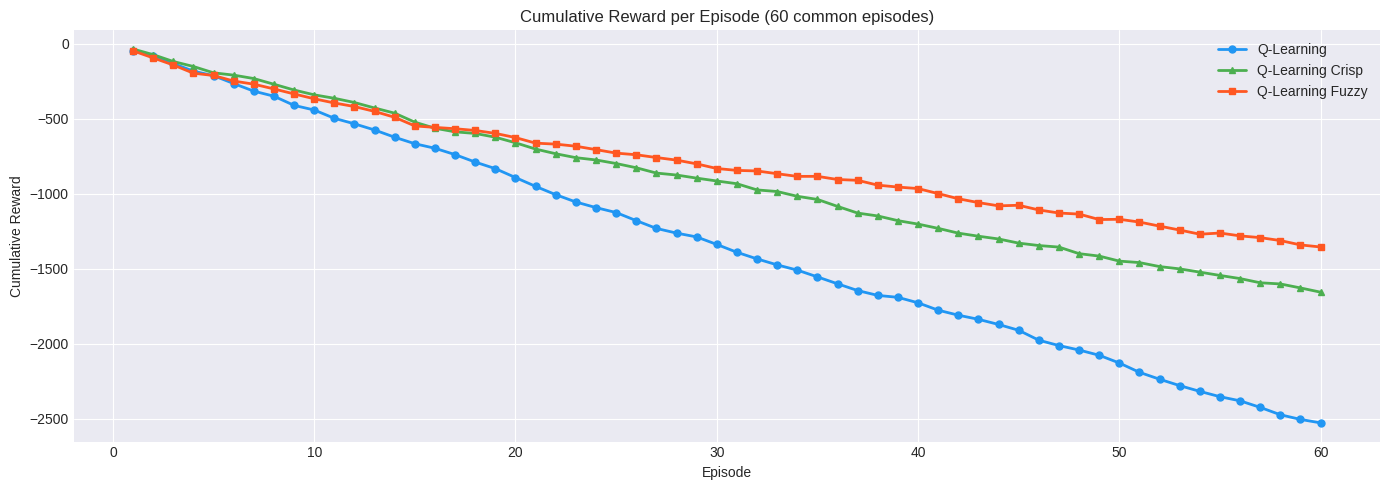

In [21]:
# Cumulative Reward per Episode - Comparison (line chart, common episodes)
fig, ax = plt.subplots(figsize=(14, 5))

for name, df_cmp in dfs_cmp.items():
    cum_per_ep = df_cmp.groupby('episode')['cumulative_reward'].last()
    ax.plot(cum_per_ep.index, cum_per_ep.values, marker=MARKERS[name], markersize=5,
            linewidth=2, label=name, color=COLORS[name])

ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Reward')
ax.set_title(f'Cumulative Reward per Episode ({len(common_episodes)} common episodes)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

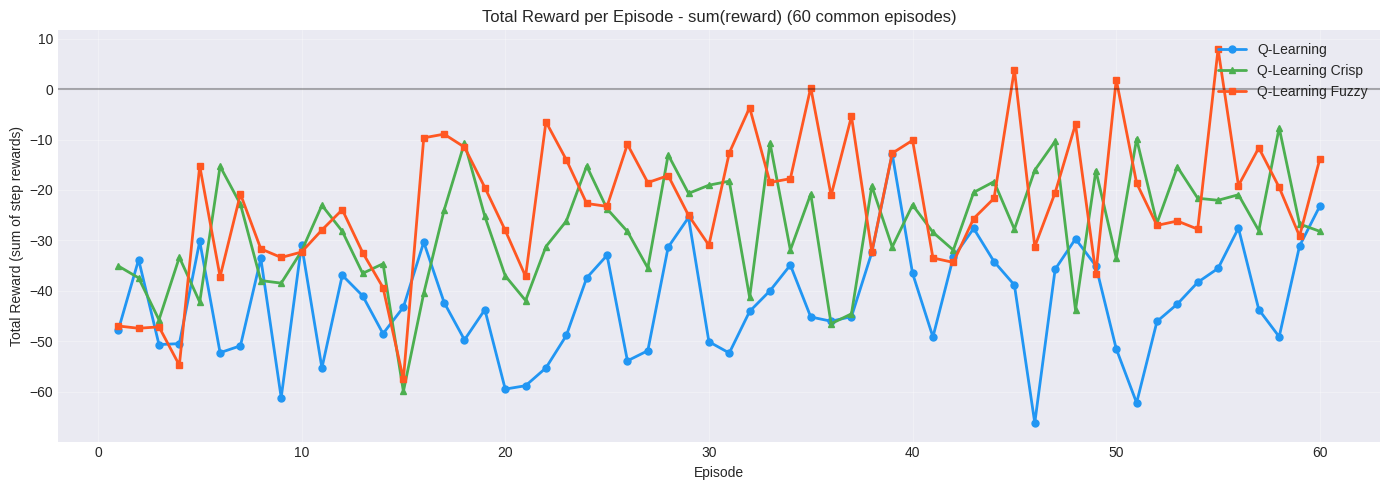

In [22]:
# Total Reward per Episode - Computed from sum(reward) per episode
# Unlike cumulative_reward field which accumulates across episodes, this resets each episode
reward_sums = {name: df_cmp.groupby('episode')['reward'].sum() for name, df_cmp in dfs_cmp.items()}

# --- Line chart ---
fig, ax = plt.subplots(figsize=(14, 5))

for name, rsum in reward_sums.items():
    ax.plot(rsum.index, rsum.values, marker=MARKERS[name], markersize=5,
            linewidth=2, label=name, color=COLORS[name])

ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward (sum of step rewards)')
ax.set_title(f'Total Reward per Episode - sum(reward) ({len(common_episodes)} common episodes)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

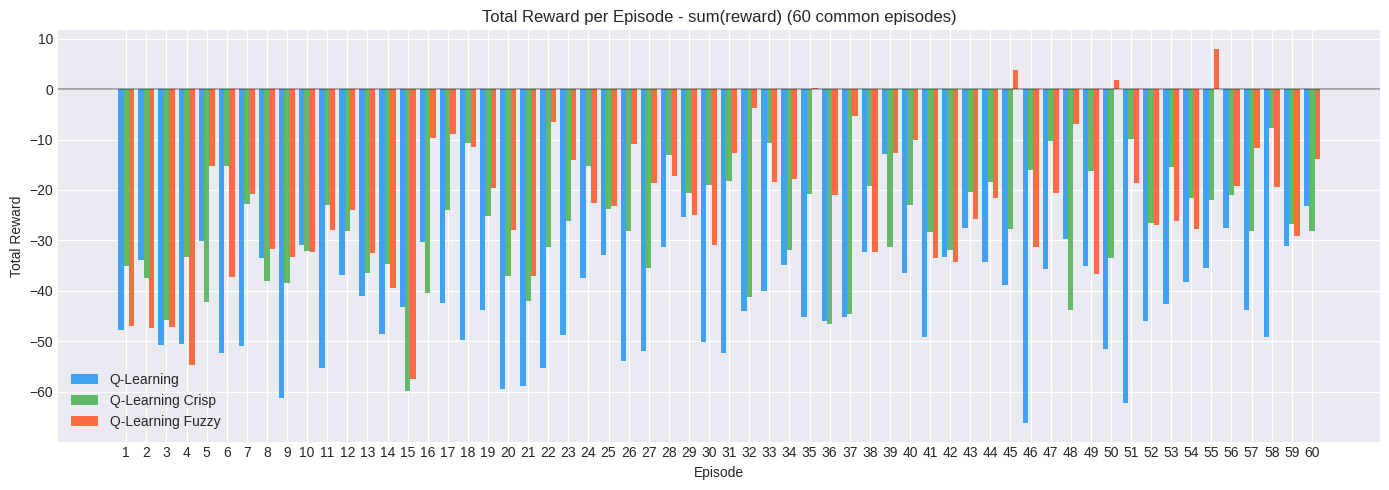


Total Reward per Episode (sum of step rewards):
 Episode        Q-Learning  Q-Learning Crisp  Q-Learning Fuzzy
--------------------------------------------------------------
       1          -47.8291          -35.0829          -46.9865
       2          -33.8268          -37.4509          -47.4398
       3          -50.6720          -45.7592          -47.1535
       4          -50.4893          -33.3597          -54.7656
       5          -30.1784          -42.2325          -15.2330
       6          -52.2810          -15.3095          -37.2064
       7          -50.9118          -22.8428          -20.8142
       8          -33.5971          -37.9726          -31.6898
       9          -61.1924          -38.4867          -33.3971
      10          -30.8714          -32.1541          -32.3181
      11          -55.3182          -23.0463          -27.9383
      12          -36.9217          -28.1977          -23.9163
      13          -41.0039          -36.5495          -32.4258
      

In [23]:
# --- Bar chart ---
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(common_episodes))
n = len(reward_sums)
width = 0.8 / n
for i, (name, rsum) in enumerate(reward_sums.items()):
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, rsum.values, width, label=name, color=COLORS[name], alpha=0.85)

ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title(f'Total Reward per Episode - sum(reward) ({len(common_episodes)} common episodes)')
ax.set_xticks(x)
ax.set_xticklabels(common_episodes)
ax.legend()

plt.tight_layout()
plt.show()

# Stats
names = list(reward_sums.keys())
print('\nTotal Reward per Episode (sum of step rewards):')
header = f'{"Episode":>8}' + ''.join(f'{name:>18}' for name in names)
print(header)
print('-' * len(header))
for ep in common_episodes:
    row = f'{ep:>8}' + ''.join(f'{reward_sums[name][ep]:>18.4f}' for name in names)
    print(row)
mean_row = f'{"Mean":>8}' + ''.join(f'{reward_sums[name].mean():>18.4f}' for name in names)
print('-' * len(header))
print(mean_row)

## 3. Per-Step Reward Analysis

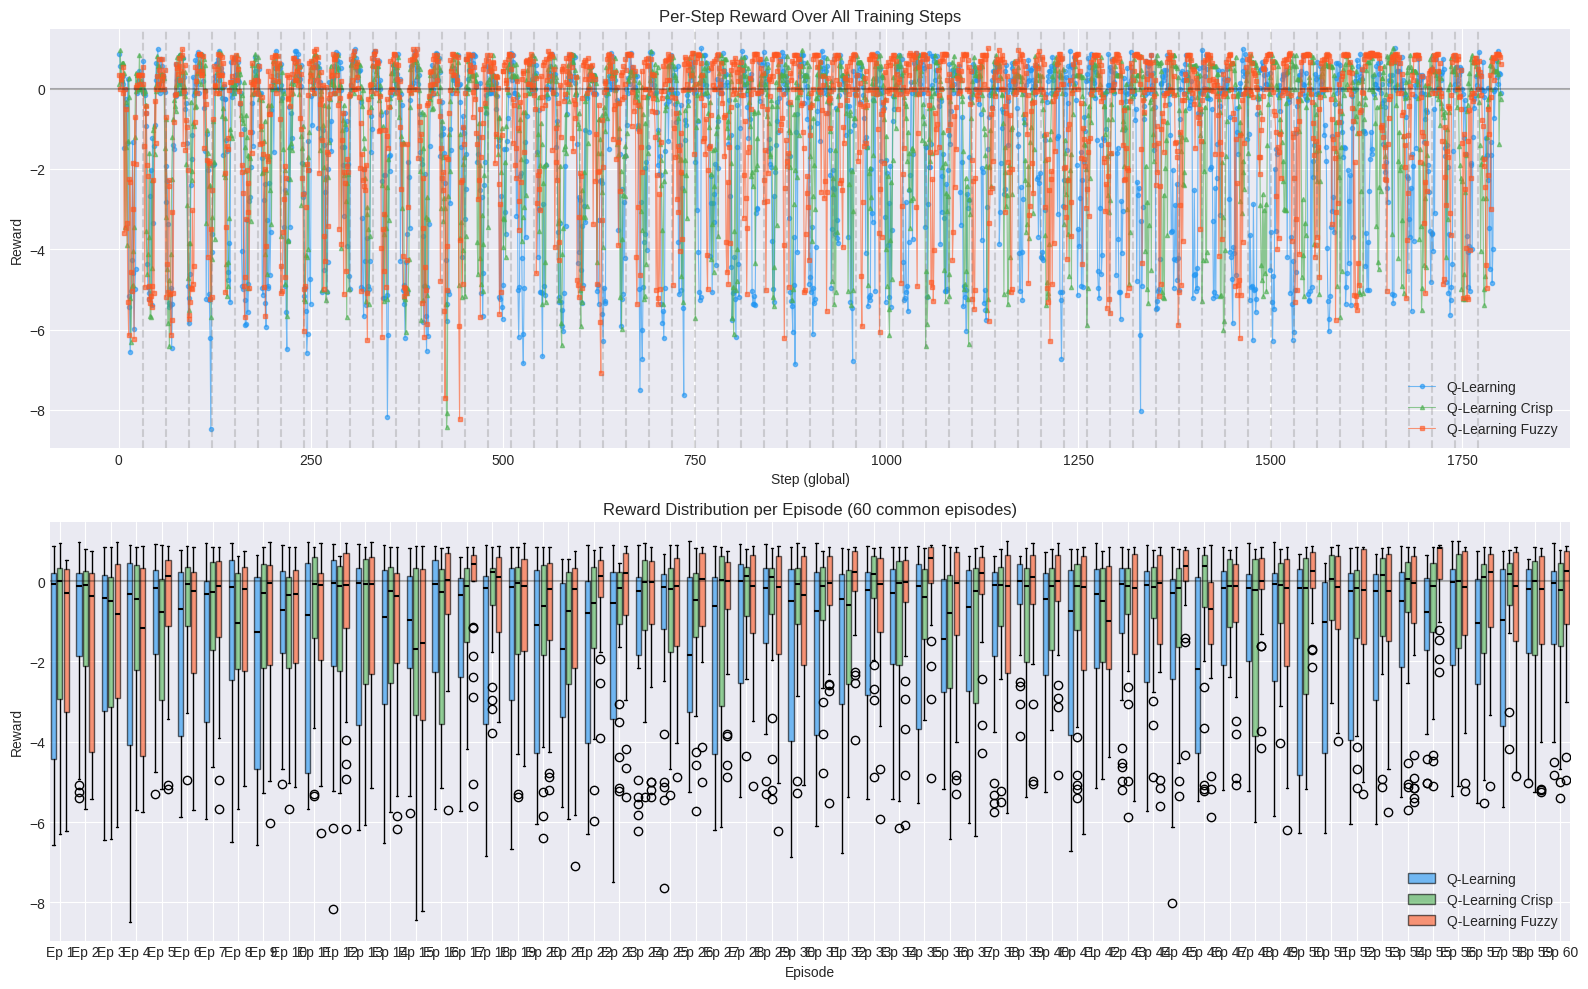

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Top: Per-step reward over all steps ---
ax = axes[0]
for name, df in dfs.items():
    steps = range(1, len(df) + 1)
    ax.plot(steps, df['reward'], marker=MARKERS[name], markersize=3, linewidth=0.8,
            label=name, color=COLORS[name], alpha=0.6)

ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Step (global)')
ax.set_ylabel('Reward')
ax.set_title('Per-Step Reward Over All Training Steps')
ax.legend()

for ep in ref_df['episode'].unique()[1:]:
    idx = ref_df[ref_df['episode'] == ep].index[0]
    ax.axvline(x=idx + 1, color='gray', linestyle='--', alpha=0.3)

# --- Bottom: Reward distribution per episode (box plot, common episodes) ---
ax = axes[1]
n = len(dfs_cmp)
group_span = n + 1  # spacing between episode groups
box_width = 0.8
handles = []
for i, (name, df_cmp) in enumerate(dfs_cmp.items()):
    rewards_by_ep = [df_cmp[df_cmp['episode'] == ep]['reward'].values for ep in common_episodes]
    positions = np.arange(len(common_episodes)) * group_span + i
    bp = ax.boxplot(rewards_by_ep, positions=positions, widths=box_width,
                    patch_artist=True, boxprops=dict(facecolor=COLORS[name], alpha=0.6),
                    medianprops=dict(color='black', linewidth=1.5))
    handles.append(bp['boxes'][0])

ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title(f'Reward Distribution per Episode ({len(common_episodes)} common episodes)')
ax.set_xticks(np.arange(len(common_episodes)) * group_span + (n - 1) / 2)
ax.set_xticklabels([f'Ep {ep}' for ep in common_episodes])
ax.legend(handles, list(dfs_cmp.keys()))
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Reward Statistics Summary

In [25]:
print('=' * 70)
print('REWARD STATISTICS SUMMARY')
print('=' * 70)

for name, df in dfs.items():
    print(f'\n--- {name} ---')
    print(f'  Total steps     : {len(df)}')
    print(f'  Episodes        : {df["episode"].nunique()}')
    print(f'  Q-Table (final) : {df["q_table_size"].iloc[-1]}')
    print(f'  Reward (mean)   : {df["reward"].mean():.4f}')
    print(f'  Reward (std)    : {df["reward"].std():.4f}')
    print(f'  Reward (min)    : {df["reward"].min():.4f}')
    print(f'  Reward (max)    : {df["reward"].max():.4f}')
    print(f'  Positive rewards: {(df["reward"] > 0).sum()} / {len(df)} ({(df["reward"] > 0).mean()*100:.1f}%)')
    print(f'  Zero rewards    : {(df["reward"] == 0).sum()} / {len(df)} ({(df["reward"] == 0).mean()*100:.1f}%)')
    print(f'  Negative rewards: {(df["reward"] < 0).sum()} / {len(df)} ({(df["reward"] < 0).mean()*100:.1f}%)')

print(f'\n{"=" * 70}')
print(f'PER-EPISODE BREAKDOWN ({len(common_episodes)} common episodes)')
print(f'{"=" * 70}')

for ep in common_episodes:
    print(f'\n  Episode {ep}:')
    for name, df_cmp in dfs_cmp.items():
        ep_df = df_cmp[df_cmp['episode'] == ep]
        print(f'    {name:<18}: cum_reward={ep_df["cumulative_reward"].iloc[-1]:.4f}, '
              f'mean_reward={ep_df["reward"].mean():.4f}, q_table={ep_df["q_table_size"].iloc[-1]}')

REWARD STATISTICS SUMMARY

--- Q-Learning ---
  Total steps     : 1800
  Episodes        : 60
  Q-Table (final) : 1853
  Reward (mean)   : -1.4051
  Reward (std)    : 2.1444
  Reward (min)    : -8.4745
  Reward (max)    : 1.0000
  Positive rewards: 637 / 1800 (35.4%)
  Zero rewards    : 2 / 1800 (0.1%)
  Negative rewards: 1161 / 1800 (64.5%)

--- Q-Learning Crisp ---
  Total steps     : 1800
  Episodes        : 60
  Q-Table (final) : 22
  Reward (mean)   : -0.9206
  Reward (std)    : 1.8118
  Reward (min)    : -8.4354
  Reward (max)    : 1.0000
  Positive rewards: 759 / 1800 (42.2%)
  Zero rewards    : 1 / 1800 (0.1%)
  Negative rewards: 1040 / 1800 (57.8%)

--- Q-Learning Fuzzy ---
  Total steps     : 1800
  Episodes        : 60
  Q-Table (final) : 24
  Reward (mean)   : -0.7532
  Reward (std)    : 1.8088
  Reward (min)    : -8.2225
  Reward (max)    : 1.0000
  Positive rewards: 796 / 1800 (44.2%)
  Zero rewards    : 0 / 1800 (0.0%)
  Negative rewards: 1004 / 1800 (55.8%)

PER-EPISODE

## 4b. Reward Sign Comparison (Positive / Negative / Zero)

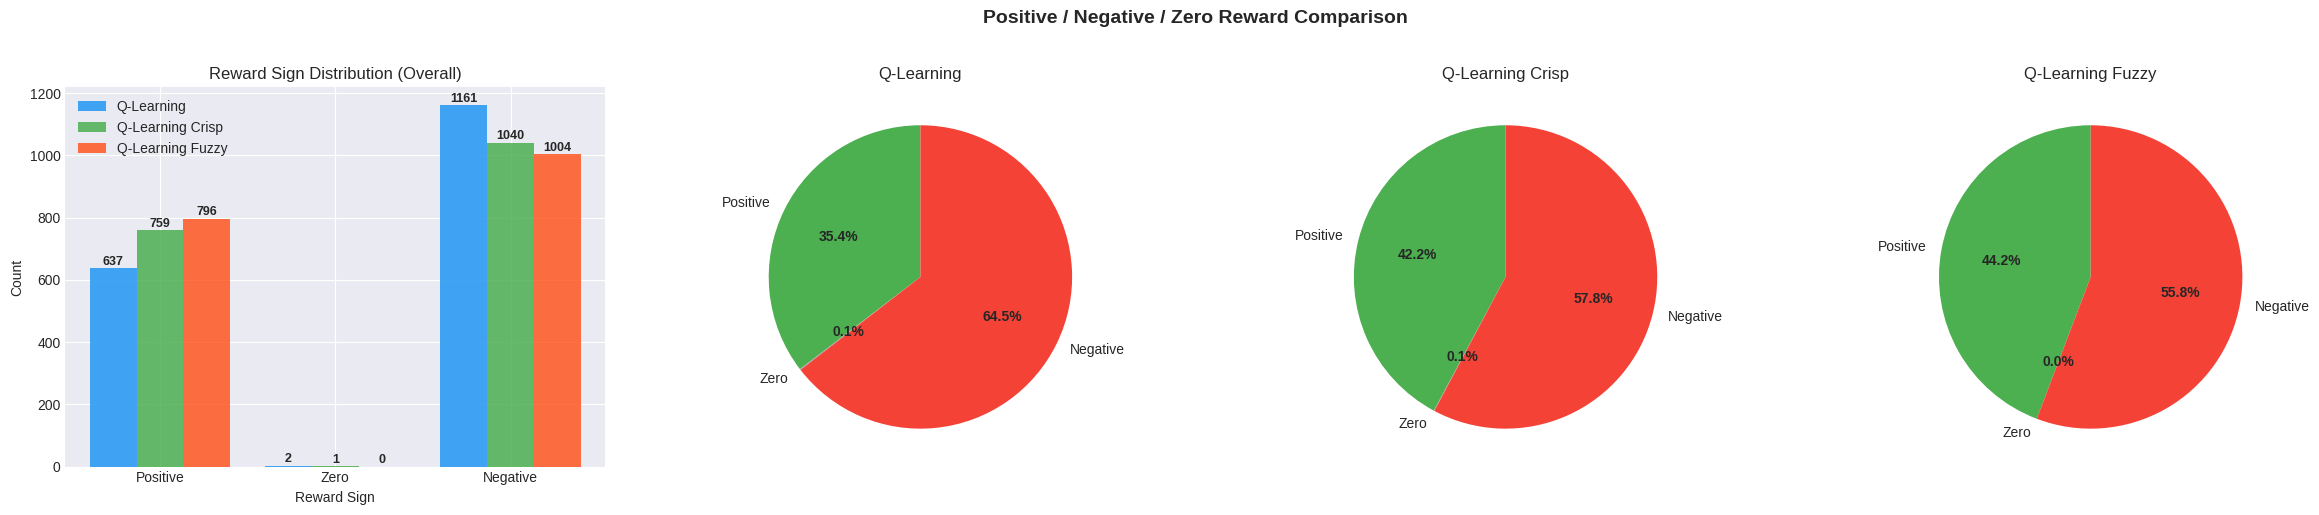

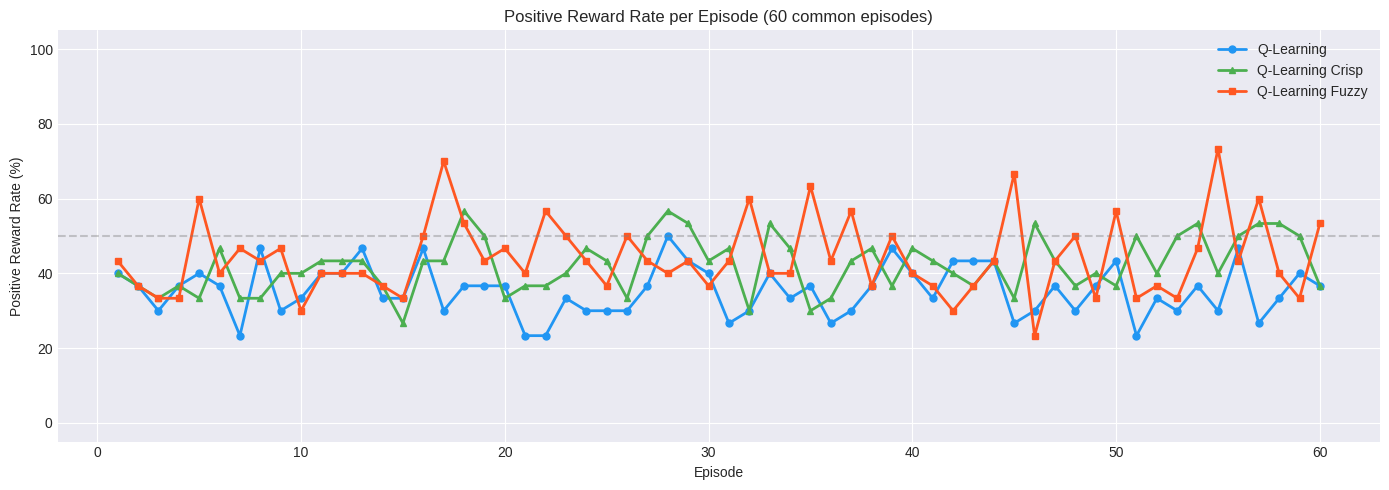

In [26]:
n = len(dfs)
fig, axes = plt.subplots(1, 1 + n, figsize=(6 * (1 + n), 5))

sign_labels = ['Positive', 'Zero', 'Negative']
sign_colors = ['#4CAF50', '#9E9E9E', '#F44336']

sign_counts = {
    name: [(df['reward'] > 0).sum(), (df['reward'] == 0).sum(), (df['reward'] < 0).sum()]
    for name, df in dfs.items()
}

# --- 1) Overall grouped bar chart comparison ---
ax = axes[0]
x = np.arange(len(sign_labels))
width = 0.8 / n
for i, (name, counts) in enumerate(sign_counts.items()):
    offset = (i - (n - 1) / 2) * width
    bars = ax.bar(x + offset, counts, width, label=name, color=COLORS[name], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 2,
                f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Reward Sign')
ax.set_ylabel('Count')
ax.set_title('Reward Sign Distribution (Overall)')
ax.set_xticks(x)
ax.set_xticklabels(sign_labels)
ax.legend()

# --- Pie chart per model ---
for j, (name, counts) in enumerate(sign_counts.items()):
    ax = axes[1 + j]
    wedges, texts, autotexts = ax.pie(
        counts, labels=sign_labels, colors=sign_colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 10})
    for t in autotexts:
        t.set_fontweight('bold')
    ax.set_title(name)

fig.suptitle('Positive / Negative / Zero Reward Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Per-episode positive reward rate (line chart) ---
fig, ax = plt.subplots(figsize=(14, 5))

for name, df_cmp in dfs_cmp.items():
    pos_rate = df_cmp.groupby('episode')['reward'].apply(lambda r: (r > 0).mean() * 100)
    ax.plot(pos_rate.index, pos_rate.values, marker=MARKERS[name], markersize=5,
            linewidth=2, label=name, color=COLORS[name])

ax.set_xlabel('Episode')
ax.set_ylabel('Positive Reward Rate (%)')
ax.set_title(f'Positive Reward Rate per Episode ({len(common_episodes)} common episodes)')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.4)
ax.legend()
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

## 5. Metrics Over Training

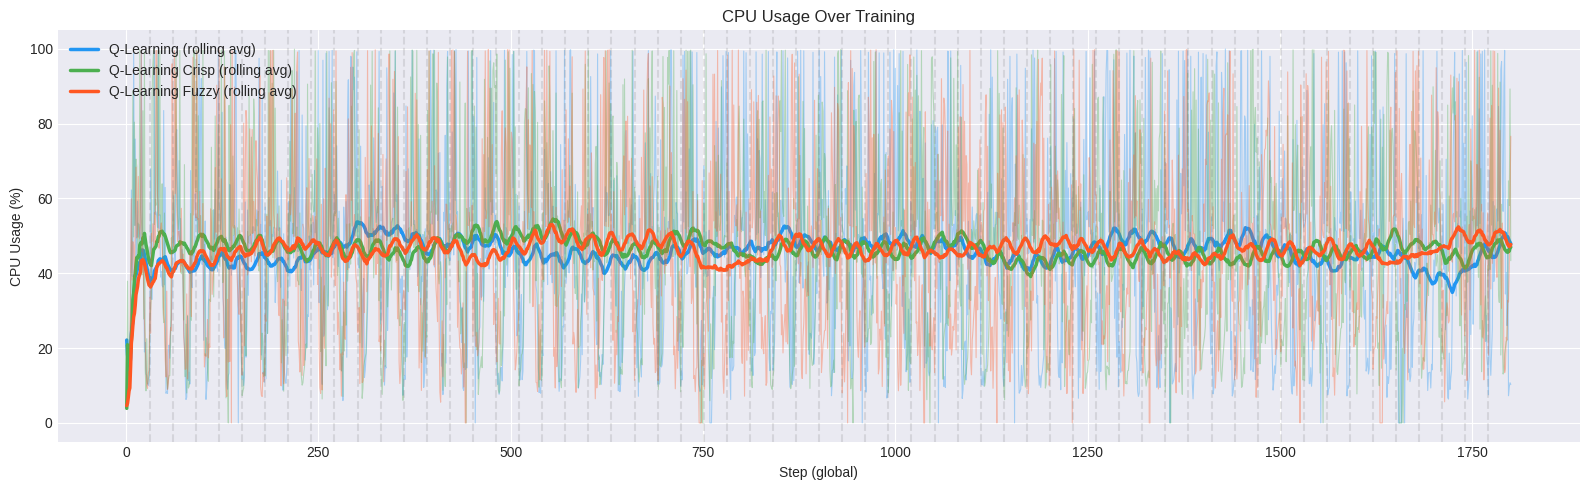

In [27]:
def plot_metric_over_training(column, ylabel, title, step_plot=False):
    fig, ax = plt.subplots(figsize=(16, 5))
    for name, df in dfs.items():
        steps = range(1, len(df) + 1)
        if step_plot:
            ax.step(steps, df[column], linewidth=0.8, color=COLORS[name], alpha=0.35, where='mid')
        else:
            ax.plot(steps, df[column], linewidth=0.8, color=COLORS[name], alpha=0.35)
        window = max(1, len(df) // 20)
        ax.plot(steps, df[column].rolling(window, min_periods=1).mean(),
                linewidth=2.5, color=COLORS[name], label=f'{name} (rolling avg)')

    for ep in ref_df['episode'].unique()[1:]:
        idx = ref_df[ref_df['episode'] == ep].index[0]
        ax.axvline(x=idx + 1, color='gray', linestyle='--', alpha=0.2)

    ax.set_xlabel('Step (global)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_metric_over_training('cpu_usage', 'CPU Usage (%)', 'CPU Usage Over Training')

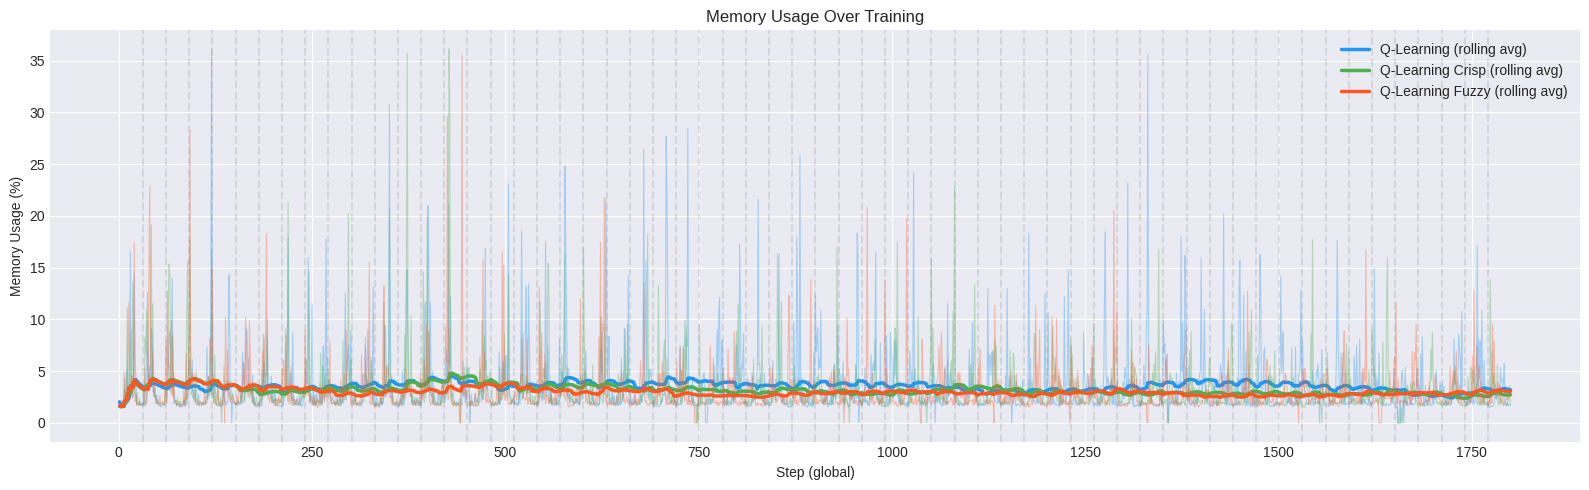

In [28]:
plot_metric_over_training('memory_usage', 'Memory Usage (%)', 'Memory Usage Over Training')

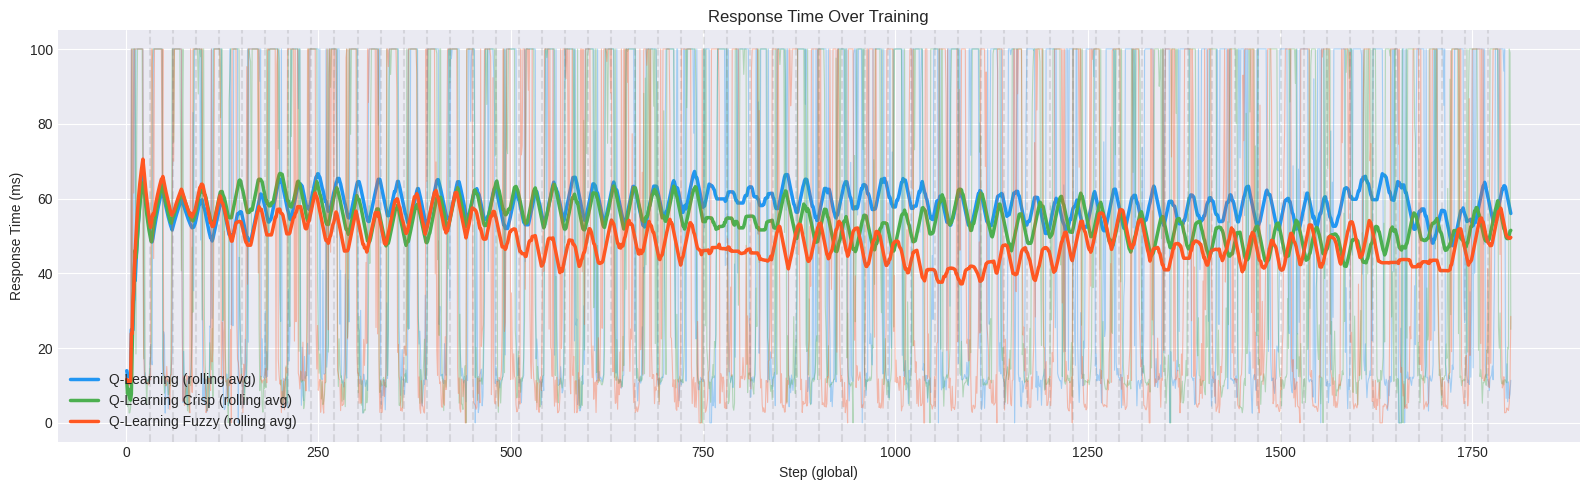

In [29]:
plot_metric_over_training('response_time', 'Response Time (ms)', 'Response Time Over Training')

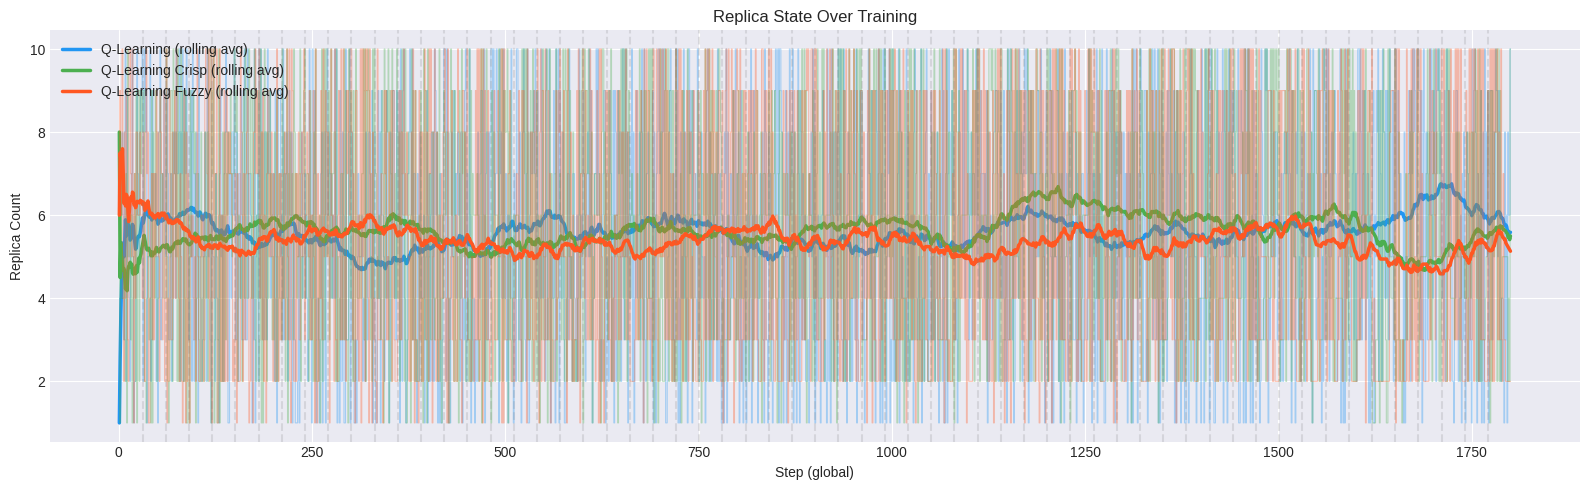

In [30]:
plot_metric_over_training('replica_state', 'Replica Count', 'Replica State Over Training', step_plot=True)

## 6. Epsilon Decay & Replica Actions

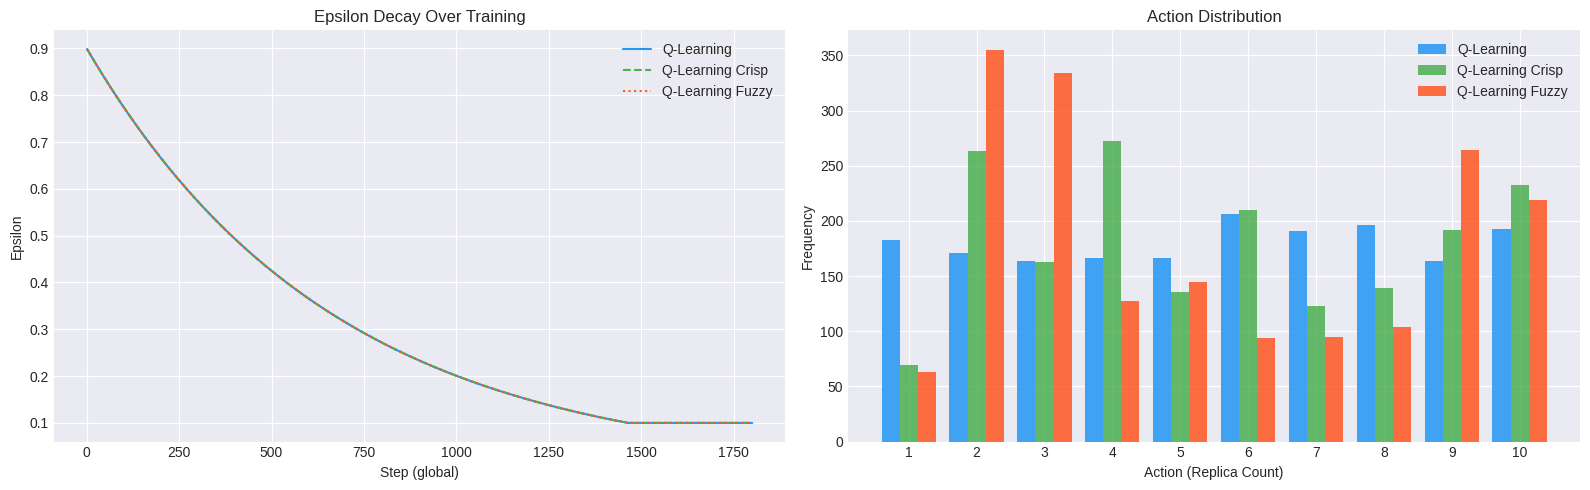

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Epsilon decay ---
ax = axes[0]
for i, (name, df) in enumerate(dfs.items()):
    ls = ['-', '--', ':'][i % 3]
    ax.plot(range(1, len(df) + 1), df['epsilon'], linewidth=1.5, linestyle=ls,
            label=name, color=COLORS[name])
ax.set_xlabel('Step (global)')
ax.set_ylabel('Epsilon')
ax.set_title('Epsilon Decay Over Training')
ax.legend()

# --- Right: Action (replica count) distribution ---
ax = axes[1]
action_counts = {name: df['action'].value_counts().sort_index() for name, df in dfs.items()}
all_actions = sorted(set().union(*[set(ac.index) for ac in action_counts.values()]))
x = np.arange(len(all_actions))
n = len(dfs)
width = 0.8 / n
for i, (name, ac) in enumerate(action_counts.items()):
    offset = (i - (n - 1) / 2) * width
    vals = [ac.get(a, 0) for a in all_actions]
    ax.bar(x + offset, vals, width, label=name, color=COLORS[name], alpha=0.85)

ax.set_xlabel('Action (Replica Count)')
ax.set_ylabel('Frequency')
ax.set_title('Action Distribution')
ax.set_xticks(x)
ax.set_xticklabels(all_actions)
ax.legend()

plt.tight_layout()
plt.show()

## 7. Reward vs Response Time & Replicas

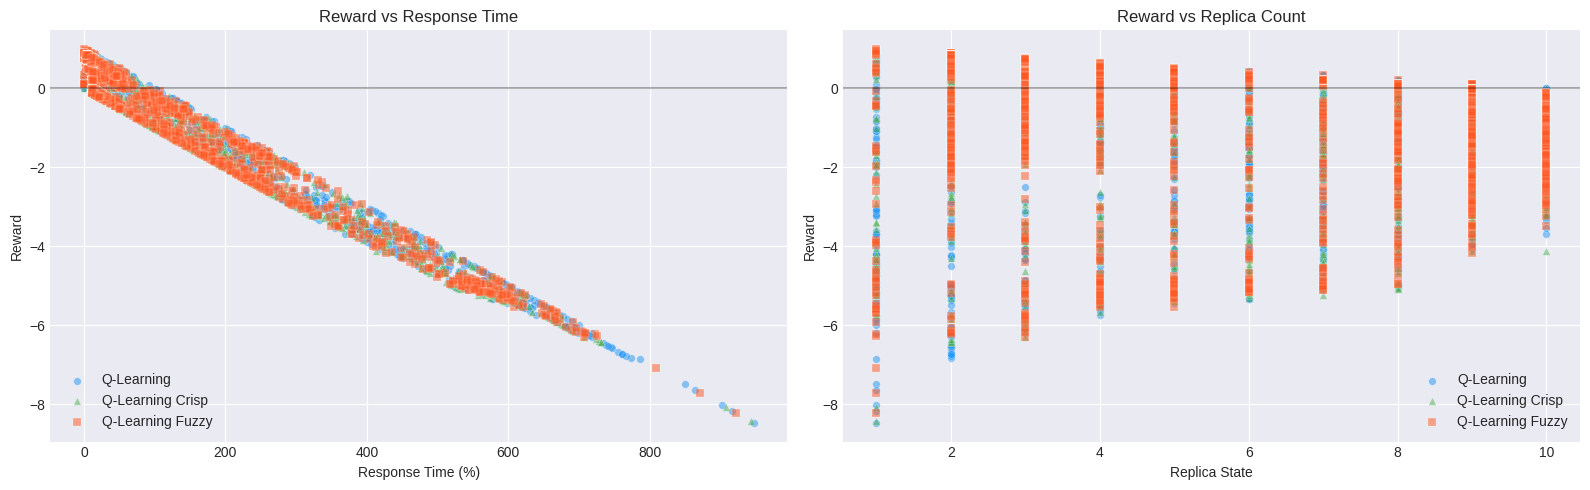

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Reward vs Response Time ---
ax = axes[0]
for name, df in dfs.items():
    ax.scatter(df['response_time_percentage'], df['reward'], alpha=0.5, s=30,
               label=name, color=COLORS[name], marker=MARKERS[name],
               edgecolors='white', linewidth=0.3)
ax.set_xlabel('Response Time (%)')
ax.set_ylabel('Reward')
ax.set_title('Reward vs Response Time')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# --- Right: Reward vs Replica State ---
ax = axes[1]
for name, df in dfs.items():
    ax.scatter(df['replica_state'], df['reward'], alpha=0.5, s=30,
               label=name, color=COLORS[name], marker=MARKERS[name],
               edgecolors='white', linewidth=0.3)
ax.set_xlabel('Replica State')
ax.set_ylabel('Reward')
ax.set_title('Reward vs Replica Count')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()